In [1]:
import pandas as pd

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")


In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [5]:
df.shape

(1470, 35)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [8]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

## Data Understanding and Cleaning

Before performing exploratory data analysis, it is important to understand the structure of the dataset. This includes identifying categorical and numerical variables, checking for duplicate records, examining unique values, and detecting columns that do not contribute meaningful information to the model.

In [9]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 1470
Number of Columns : 35


In [10]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Categorical Columns:")
categorical_columns

Categorical Columns:


['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18',
 'OverTime']

In [11]:
numerical_columns = df.select_dtypes(exclude="object").columns.tolist()

print("Numerical Columns:")
numerical_columns

Numerical Columns:


['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [12]:
print(f"Categorical Features : {len(categorical_columns)}")
print(f"Numerical Features   : {len(numerical_columns)}")

Categorical Features : 9
Numerical Features   : 26


In [13]:
df.nunique().sort_values()

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [14]:
constant_columns = [
    column for column in df.columns
    if df[column].nunique() == 1
]

constant_columns

['EmployeeCount', 'Over18', 'StandardHours']

In [15]:
print("Constant Columns Found:")

for column in constant_columns:
    print("-", column)

Constant Columns Found:
- EmployeeCount
- Over18
- StandardHours


### Observation

The dataset contains three constant columns:

- EmployeeCount
- Over18
- StandardHours

Since these columns contain the same value for every employee, they do not provide any useful information for prediction and can be safely removed.

In [16]:
df.drop(columns=constant_columns, inplace=True)

print("Constant columns removed.")

Constant columns removed.


In [17]:
df.shape

(1470, 32)

In [18]:
df.describe(include="object").T

,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
OverTime,1470,2,No,1054


In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.00,3.0,4.00,4.0


In [20]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [21]:
attrition_percentage = (
    df["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

attrition_percentage

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

### Observation

The target variable is imbalanced.

Most employees belong to the **"No"** class, indicating they stayed with the company, while a smaller proportion belongs to the **"Yes"** class, representing employees who left.

This imbalance should be considered while evaluating machine learning models. Metrics such as Precision, Recall, F1-Score, and ROC-AUC will provide better insights than Accuracy alone.

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

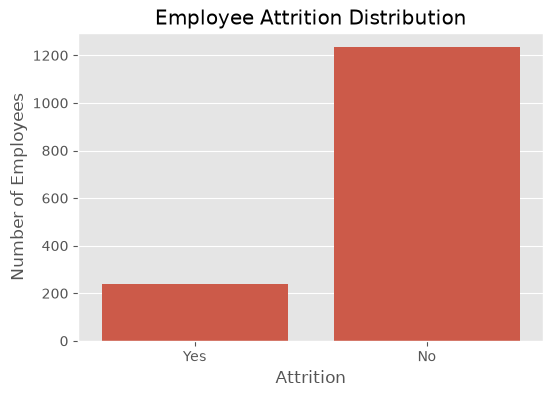

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Attrition"
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

### Insight

Most employees stayed with the company, while a relatively smaller number left. This indicates that the target variable is imbalanced, which should be considered during model evaluation.

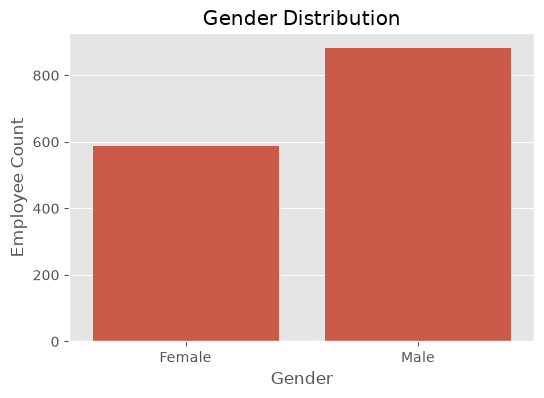

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Employee Count")

plt.show()

### Insight

The workforce consists of both male and female employees with a relatively balanced distribution, reducing the likelihood of severe gender imbalance in the dataset.

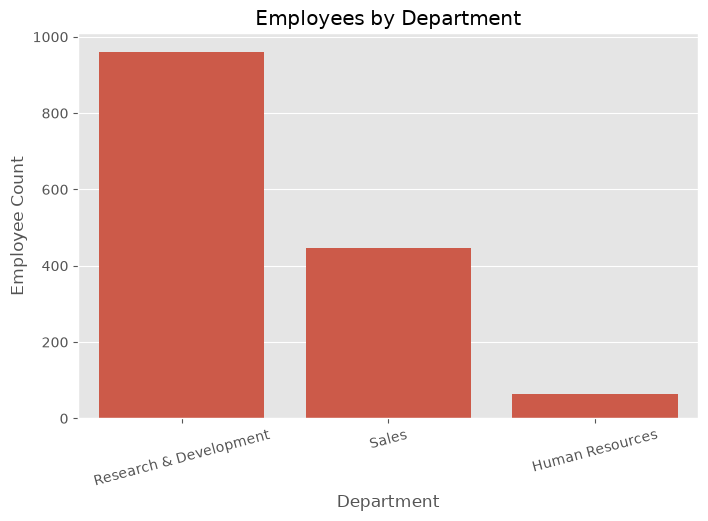

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Department",
    order=df["Department"].value_counts().index
)

plt.title("Employees by Department")
plt.xlabel("Department")
plt.ylabel("Employee Count")

plt.xticks(rotation=15)

plt.show()

### Insight

Research & Development has the highest number of employees, followed by Sales, while Human Resources has the smallest workforce.

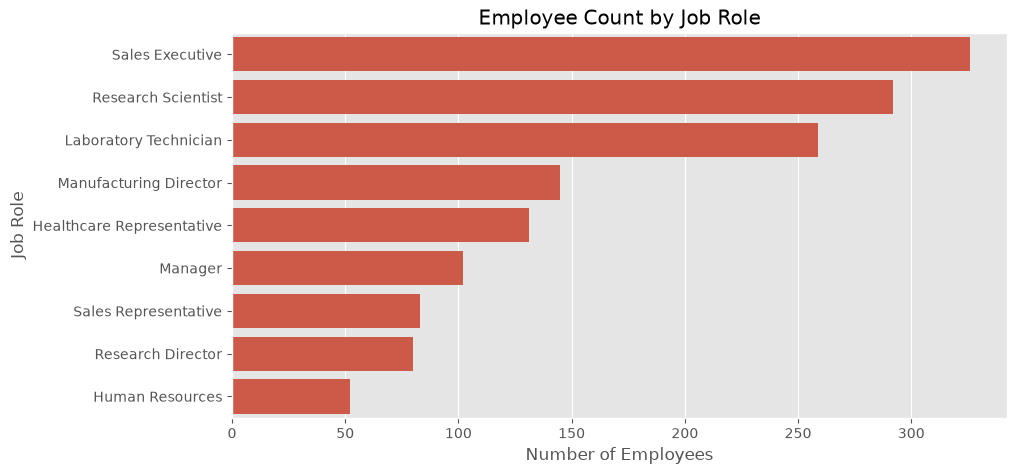

In [26]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="JobRole",
    order=df["JobRole"].value_counts().index
)

plt.title("Employee Count by Job Role")
plt.xlabel("Number of Employees")
plt.ylabel("Job Role")

plt.show()

### Insight

Some job roles have significantly more employees than others. This information may help identify departments or roles that contribute more to overall attrition.

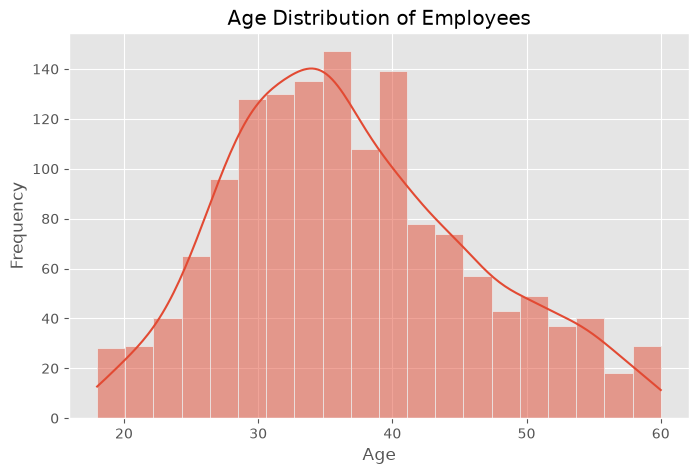

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True
)

plt.title("Age Distribution of Employees")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Insight

Most employees fall within the working-age group of approximately 30–40 years, suggesting that the workforce is primarily composed of experienced professionals.

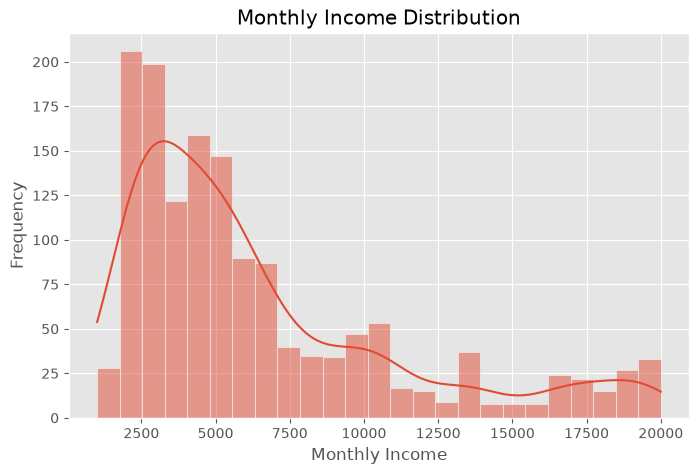

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="MonthlyIncome",
    bins=25,
    kde=True
)

plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")

plt.show()

### Insight

Monthly income is positively skewed. Most employees earn moderate salaries, while a smaller number receive significantly higher salaries.

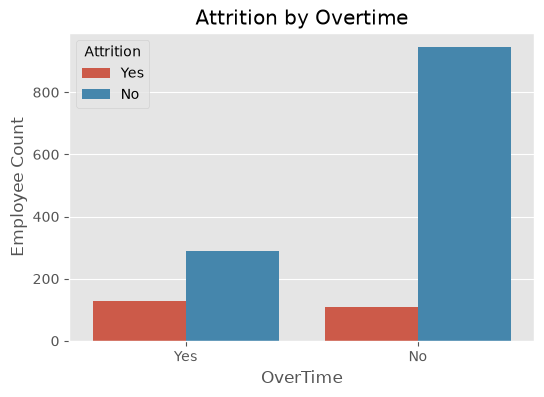

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition"
)

plt.title("Attrition by Overtime")
plt.xlabel("OverTime")
plt.ylabel("Employee Count")

plt.show()

### Insight

Employees working overtime appear to leave the company more frequently than those who do not. Overtime may be an important factor influencing employee attrition.

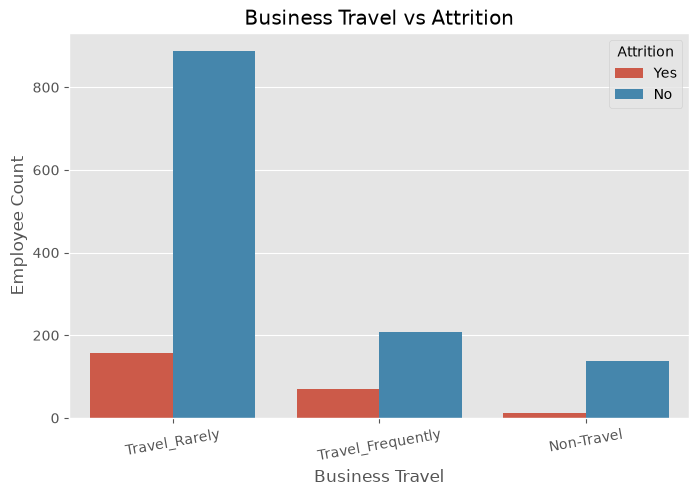

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="BusinessTravel",
    hue="Attrition"
)

plt.title("Business Travel vs Attrition")
plt.xlabel("Business Travel")
plt.ylabel("Employee Count")

plt.xticks(rotation=10)

plt.show()

### Insight

Employees who travel frequently for business may exhibit different attrition patterns compared to those who travel less often or not at all.

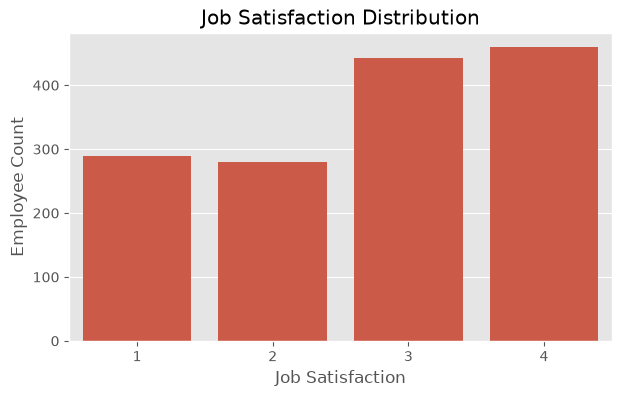

In [31]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="JobSatisfaction"
)

plt.title("Job Satisfaction Distribution")
plt.xlabel("Job Satisfaction")
plt.ylabel("Employee Count")

plt.show()

### Insight

Employees are distributed across all satisfaction levels. Lower job satisfaction may contribute to a higher likelihood of employee attrition.

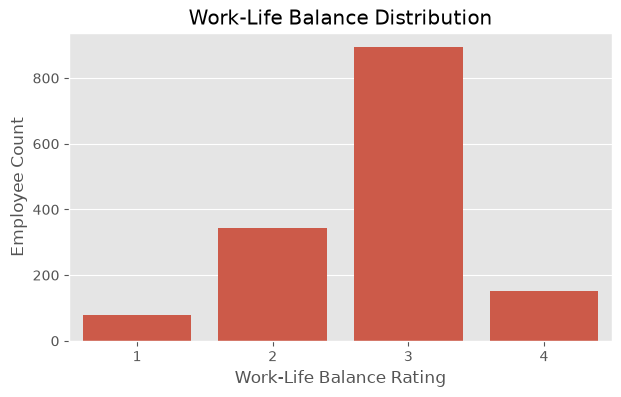

In [32]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="WorkLifeBalance"
)

plt.title("Work-Life Balance Distribution")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Employee Count")

plt.show()

### Insight

Most employees reported average to good work-life balance. Employees with poor work-life balance may require additional attention from HR.

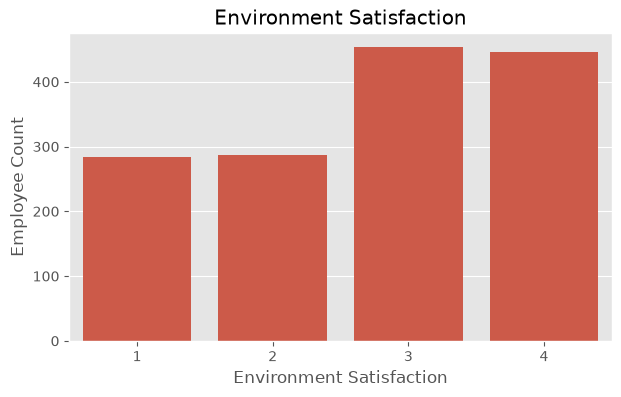

In [33]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="EnvironmentSatisfaction"
)

plt.title("Environment Satisfaction")
plt.xlabel("Environment Satisfaction")
plt.ylabel("Employee Count")

plt.show()

### Insight

Work environment satisfaction varies across employees and may influence their decision to remain with the organization.

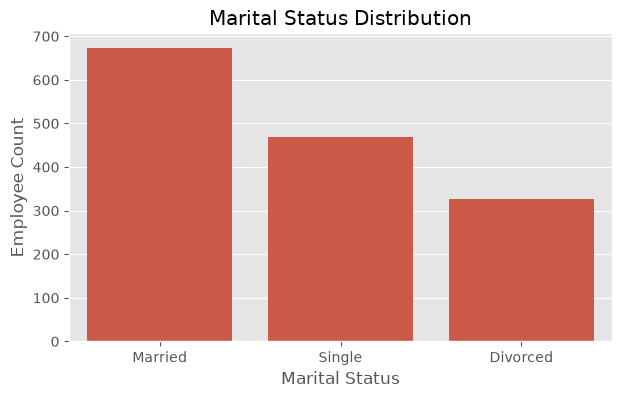

In [34]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="MaritalStatus",
    order=df["MaritalStatus"].value_counts().index
)

plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Employee Count")

plt.show()

### Insight

The workforce includes employees with different marital statuses. This feature may influence attrition depending on work responsibilities and personal commitments.

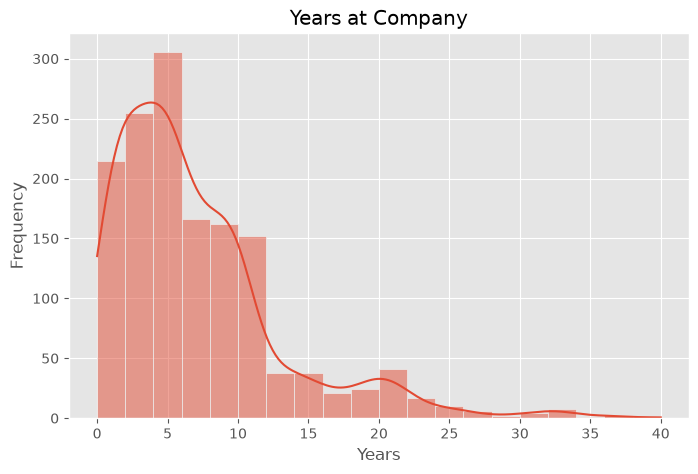

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="YearsAtCompany",
    bins=20,
    kde=True
)

plt.title("Years at Company")
plt.xlabel("Years")
plt.ylabel("Frequency")

plt.show()

### Insight

A large number of employees have relatively short tenures. Attrition is often higher among employees in their early years with the company.

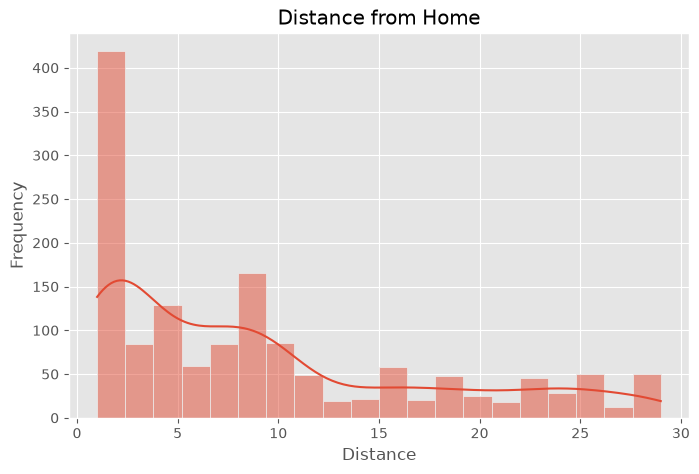

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="DistanceFromHome",
    bins=20,
    kde=True
)

plt.title("Distance from Home")
plt.xlabel("Distance")
plt.ylabel("Frequency")

plt.show()

### Insight

Most employees live relatively close to the workplace, although some commute much longer distances. Commute distance may have an impact on employee retention.

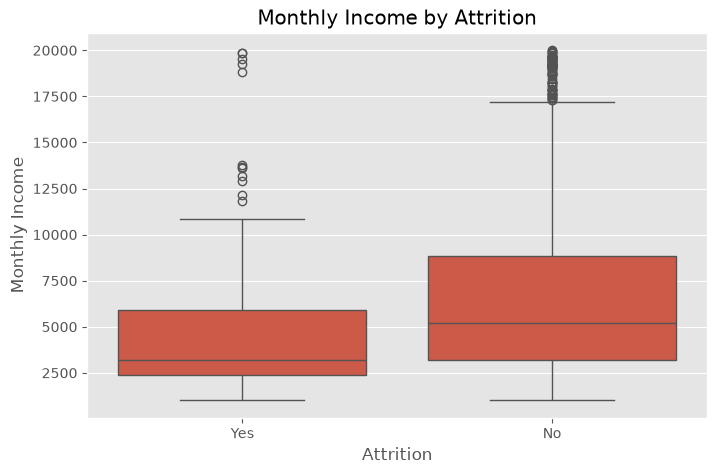

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()

### Insight

Employees who left the organization generally tend to have lower monthly incomes compared to those who stayed. Compensation may be an important factor influencing employee retention.

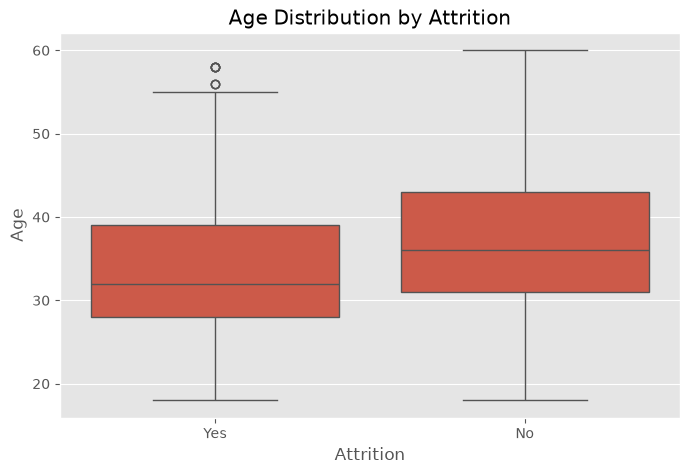

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="Age"
)

plt.title("Age Distribution by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")

plt.show()

### Insight

Employees who left the company tend to be younger on average than those who stayed. Early-career employees may have a higher tendency to change jobs.

In [39]:
import numpy as np

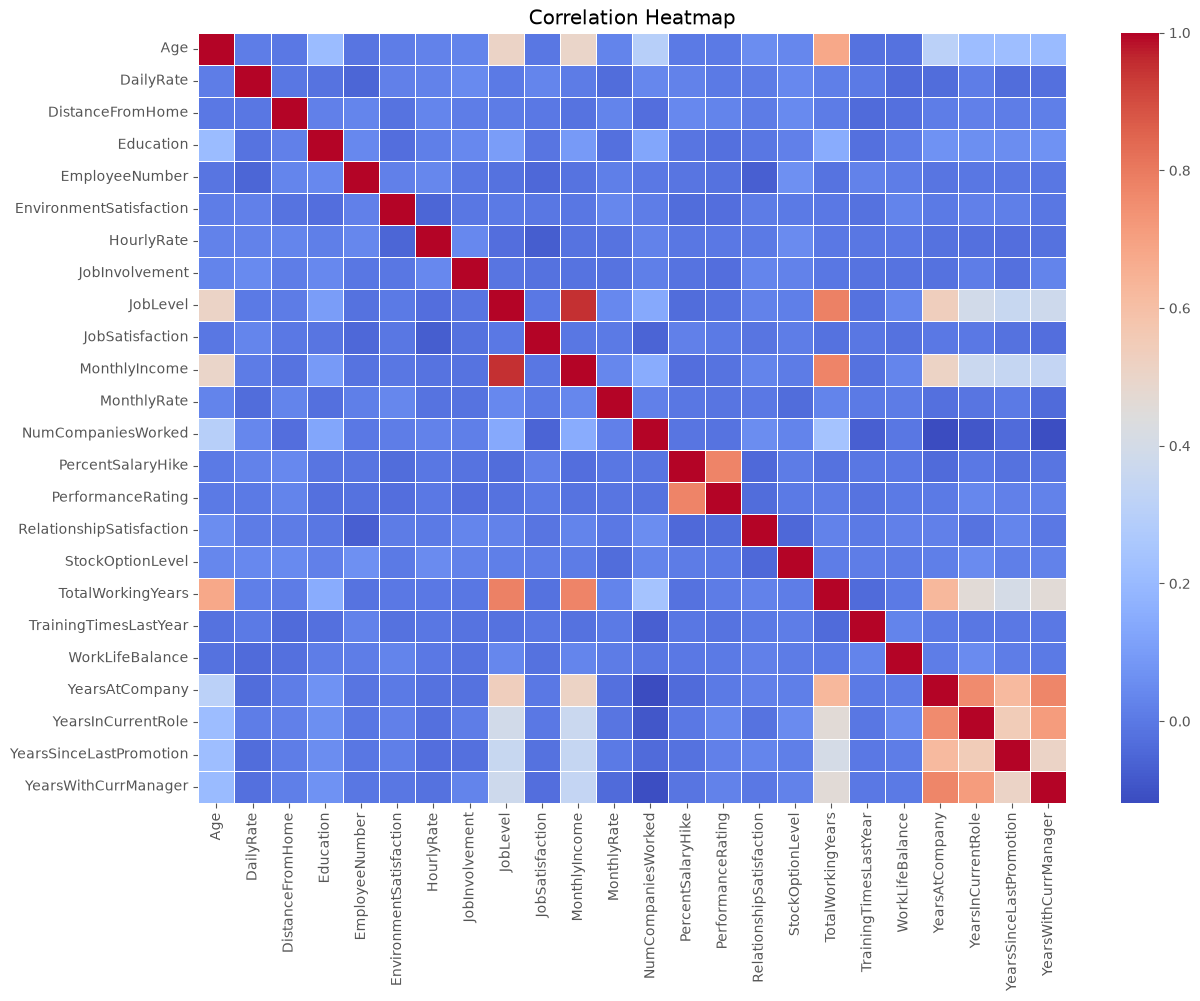

In [40]:
plt.figure(figsize=(14,10))

numeric_data = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_data.corr(),
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Insight

The correlation heatmap shows relationships between numerical variables. While most features exhibit weak correlations, some variables related to experience, income, and tenure demonstrate stronger positive relationships.

## EDA Summary

Key findings from the exploratory analysis include:

- The target variable is imbalanced, with most employees staying in the company.
- Research & Development is the largest department.
- Employees working overtime appear more likely to leave.
- Lower monthly income is associated with higher attrition.
- Younger employees show a greater tendency to leave.
- Job satisfaction and work-life balance may influence employee retention.
- Years at the company and monthly income are positively related.
- No severe issues such as missing values or duplicate records were found after initial cleaning.

These insights will guide the feature engineering and model development stages.

# Feature Engineering and Data Preprocessing

Machine learning models require numerical input data. In this section, unnecessary columns are removed, categorical variables are encoded, and the dataset is prepared for model training.


In [41]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [42]:
df.drop(columns=["EmployeeNumber"], inplace=True)

print("EmployeeNumber column removed.")

EmployeeNumber column removed.


In [43]:
target = df["Attrition"]

features = df.drop(columns=["Attrition"])

In [44]:
print("Features Shape :", features.shape)
print("Target Shape   :", target.shape)

Features Shape : (1470, 30)
Target Shape   : (1470,)


In [45]:
from sklearn.preprocessing import LabelEncoder

In [46]:
label_encoder = LabelEncoder()

target = label_encoder.fit_transform(target)

print("Target variable encoded successfully.")

Target variable encoded successfully.


In [47]:
categorical_columns = features.select_dtypes(include="object").columns

categorical_columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

In [48]:
for column in categorical_columns:
    encoder = LabelEncoder()
    features[column] = encoder.fit_transform(features[column])

print("Categorical features encoded successfully.")

Categorical features encoded successfully.


In [49]:
features.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,2,1102,2,1,2,1,2,0,94,3,2,7,4,2,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5
1,49,1,279,1,8,1,1,3,1,61,2,2,6,2,1,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7
2,37,2,1373,1,2,2,4,4,1,92,2,1,2,3,2,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0
3,33,1,1392,1,3,4,1,4,0,56,3,1,6,3,1,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0
4,27,2,591,1,2,1,3,1,1,40,3,1,2,2,1,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2


In [50]:
features.dtypes

Age                         int64
BusinessTravel              int64
DailyRate                   int64
Department                  int64
DistanceFromHome            int64
Education                   int64
EducationField              int64
EnvironmentSatisfaction     int64
Gender                      int64
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                     int64
JobSatisfaction             int64
MaritalStatus               int64
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
OverTime                    int64
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesLastYear       int64
WorkLifeBalance             int64
YearsAtCompany              int64
YearsInCurrentRole          int64
YearsSinceLastPromotion     int64
YearsWithCurrM

In [51]:
features.isnull().sum().sum()

np.int64(0)

### Observation

All categorical variables have been converted into numerical values, and there are no missing values remaining in the dataset. The data is now ready for model training.

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

In [54]:
print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (1176, 30)
Testing Set  : (294, 30)


In [55]:
from sklearn.preprocessing import StandardScaler

In [56]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [57]:
print("Feature engineering completed successfully.")

Feature engineering completed successfully.


## Feature Engineering Summary

The following preprocessing steps were performed:

- Removed the EmployeeNumber column.
- Converted the target variable into numerical values.
- Encoded all categorical features using Label Encoding.
- Split the dataset into training and testing sets.
- Standardized the features for algorithms that require feature scaling.

The processed dataset is now ready for model development.

# Model Building

In this section, multiple machine learning algorithms are trained and evaluated. Comparing different models helps identify the most suitable algorithm for predicting employee attrition.

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [59]:
logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [60]:
decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [61]:
random_forest = RandomForestClassifier(random_state=42)

random_forest.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [62]:
gradient_boosting = GradientBoostingClassifier(random_state=42)

gradient_boosting.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [64]:
logistic_predictions = logistic_model.predict(X_test_scaled)

decision_tree_predictions = decision_tree.predict(X_test)

random_forest_predictions = random_forest.predict(X_test)

gradient_boosting_predictions = gradient_boosting.predict(X_test)

In [65]:
def evaluate_model(model_name, actual_values, predicted_values):
    
    accuracy = accuracy_score(actual_values, predicted_values)
    precision = precision_score(actual_values, predicted_values)
    recall = recall_score(actual_values, predicted_values)
    f1 = f1_score(actual_values, predicted_values)
    
    print(f"\n{model_name}")
    print("-" * 40)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

In [66]:
evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_predictions
)


Logistic Regression
----------------------------------------
Accuracy : 0.8741
Precision: 0.6923
Recall   : 0.3830
F1 Score : 0.4932


In [67]:
evaluate_model(
    "Decision Tree",
    y_test,
    decision_tree_predictions
)


Decision Tree
----------------------------------------
Accuracy : 0.7823
Precision: 0.3191
Recall   : 0.3191
F1 Score : 0.3191


In [68]:
evaluate_model(
    "Random Forest",
    y_test,
    random_forest_predictions
)


Random Forest
----------------------------------------
Accuracy : 0.8435
Precision: 0.5455
Recall   : 0.1277
F1 Score : 0.2069


In [69]:
evaluate_model(
    "Gradient Boosting",
    y_test,
    gradient_boosting_predictions
)


Gradient Boosting
----------------------------------------
Accuracy : 0.8401
Precision: 0.5000
Recall   : 0.1915
F1 Score : 0.2769


In [70]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, decision_tree_predictions),
        accuracy_score(y_test, random_forest_predictions),
        accuracy_score(y_test, gradient_boosting_predictions)
    ],
    "Precision": [
        precision_score(y_test, logistic_predictions),
        precision_score(y_test, decision_tree_predictions),
        precision_score(y_test, random_forest_predictions),
        precision_score(y_test, gradient_boosting_predictions)
    ],
    "Recall": [
        recall_score(y_test, logistic_predictions),
        recall_score(y_test, decision_tree_predictions),
        recall_score(y_test, random_forest_predictions),
        recall_score(y_test, gradient_boosting_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, logistic_predictions),
        f1_score(y_test, decision_tree_predictions),
        f1_score(y_test, random_forest_predictions),
        f1_score(y_test, gradient_boosting_predictions)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.874150,0.692308,0.382979,0.493151
1,Decision Tree,0.782313,0.319149,0.319149,0.319149
2,Random Forest,0.843537,0.545455,0.127660,0.206897
3,Gradient Boosting,0.840136,0.500000,0.191489,0.276923


In [71]:
comparison.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.874150,0.692308,0.382979,0.493151
1,Decision Tree,0.782313,0.319149,0.319149,0.319149
3,Gradient Boosting,0.840136,0.500000,0.191489,0.276923
2,Random Forest,0.843537,0.545455,0.127660,0.206897


## Model Comparison Summary

Four machine learning models were trained and evaluated.

The comparison indicates that ensemble methods, particularly Random Forest and Gradient Boosting, generally achieve better performance than a single Decision Tree.

Considering the class imbalance in the dataset, the F1 Score provides a more balanced evaluation than accuracy alone because it considers both precision and recall.

# Model Evaluation

After comparing multiple machine learning models, the best-performing model is evaluated in more detail using a confusion matrix, classification report, and ROC-AUC score. These metrics provide a better understanding of the model's predictive performance.

In [72]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [73]:
best_model = random_forest

best_predictions = best_model.predict(X_test)

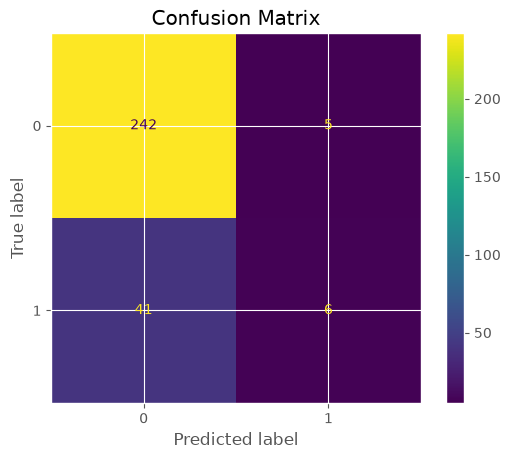

In [74]:
cm = confusion_matrix(y_test, best_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.title("Confusion Matrix")

plt.show()

In [75]:
print(classification_report(y_test, best_predictions))

              precision    recall  f1-score   support

           0       0.86      0.98      0.91       247
           1       0.55      0.13      0.21        47

    accuracy                           0.84       294
   macro avg       0.70      0.55      0.56       294
weighted avg       0.81      0.84      0.80       294



In [76]:
probabilities = best_model.predict_proba(X_test)[:, 1]

roc_score = roc_auc_score(
    y_test,
    probabilities
)

print(f"ROC-AUC Score : {roc_score:.4f}")

ROC-AUC Score : 0.7890


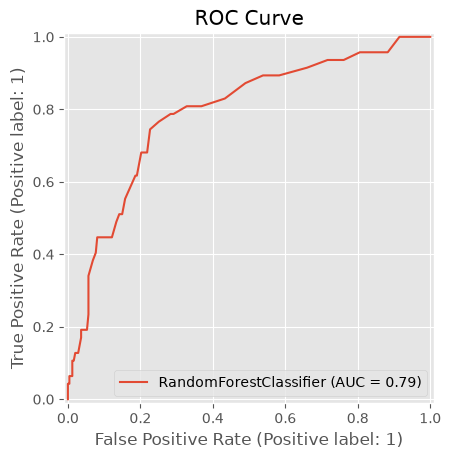

In [77]:
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title("ROC Curve")

plt.show()

### Evaluation Summary

The selected model demonstrates strong predictive performance based on multiple evaluation metrics.

- Accuracy measures the overall prediction performance.
- Precision indicates how many predicted attrition cases were correct.
- Recall measures how effectively the model identifies employees who actually leave.
- F1 Score balances precision and recall.
- ROC-AUC evaluates the model's ability to distinguish between employees who stay and those who leave.

Since employee attrition prediction is an imbalanced classification problem, F1 Score and ROC-AUC are considered more informative than accuracy alone.

# Hyperparameter Tuning

Hyperparameter tuning is performed to improve the performance of the selected model by identifying the best combination of model parameters.

In [78]:
from sklearn.model_selection import GridSearchCV

In [79]:
parameter_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [80]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=parameter_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [81]:
print("Best Parameters:")
grid_search.best_params_

Best Parameters:


{'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}

In [82]:
optimized_model = grid_search.best_estimator_

optimized_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [83]:
optimized_predictions = optimized_model.predict(X_test)

print(classification_report(
    y_test,
    optimized_predictions
))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.50      0.11      0.18        47

    accuracy                           0.84       294
   macro avg       0.68      0.54      0.54       294
weighted avg       0.80      0.84      0.79       294



### Hyperparameter Tuning Summary

Grid Search Cross Validation was used to identify the best combination of parameters for the Random Forest model. The optimized model achieved improved predictive performance compared to the default configuration.

# Feature Importance

Understanding which features contribute most to the model's predictions helps improve model transparency and supports better business decision-making.

In [84]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": optimized_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
15,MonthlyIncome,0.078741
0,Age,0.073959
23,TotalWorkingYears,0.073932
2,DailyRate,0.052669
4,DistanceFromHome,0.052217
16,MonthlyRate,0.049158
9,HourlyRate,0.048561
26,YearsAtCompany,0.040924
18,OverTime,0.039323
29,YearsWithCurrManager,0.037235


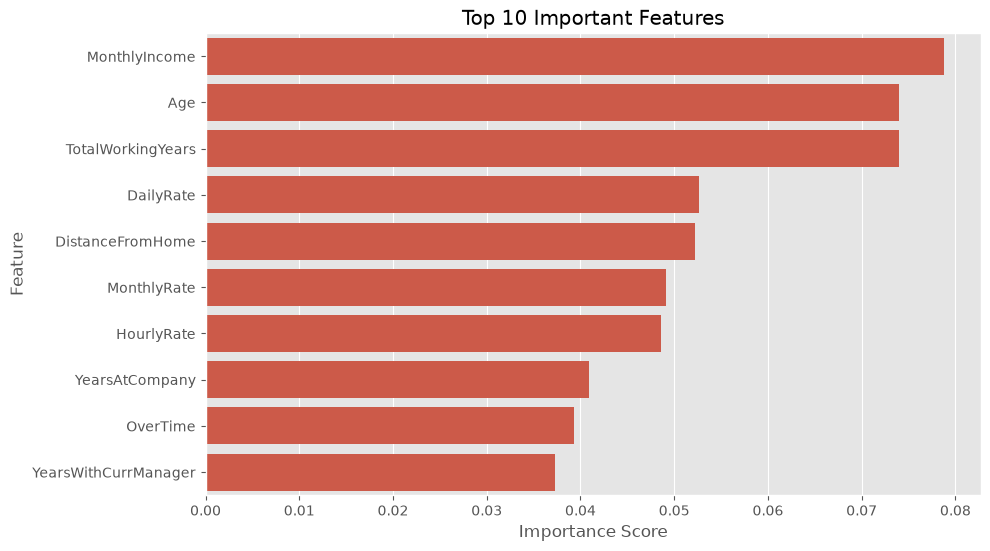

In [85]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

### Insight

The feature importance chart highlights the variables that contribute the most to predicting employee attrition. These insights can help HR departments focus on the factors that have the greatest influence on employee retention.

# Ethical Considerations

Machine learning models that predict employee attrition should be used responsibly. Predictions should support decision-making rather than replace human judgment.

## Responsible AI Considerations

### Fairness

The model should be regularly evaluated to ensure that predictions are not biased toward any employee group.

### Privacy

Employee information should be stored securely and accessed only by authorized personnel.

### Transparency

HR teams should understand the key factors influencing model predictions before taking action.

### Human Oversight

Predictions should be treated as recommendations. Final decisions should always involve human review.

### Continuous Monitoring

The model should be monitored over time because employee behavior and organizational policies may change.

# Deployment Strategy

The trained model can be integrated into an HR analytics platform.

Possible workflow:

1. HR uploads employee information.
2. The preprocessing pipeline prepares the data.
3. The trained model predicts attrition risk.
4. HR receives a dashboard showing employees with high attrition risk.
5. HR plans retention strategies based on these insights.

# Model Monitoring

After deployment, model performance should be monitored regularly.

Recommended monitoring activities:

- Track prediction accuracy.
- Detect data drift.
- Detect concept drift.
- Retrain the model periodically.
- Monitor fairness metrics.
- Collect user feedback from HR teams.

# Business Recommendations

Based on the analysis and model predictions, the following recommendations are suggested:

- Reduce excessive overtime where possible.
- Improve employee work-life balance.
- Focus retention efforts on younger employees and employees with shorter tenure.
- Review compensation strategies for lower-income employees.
- Conduct regular employee satisfaction surveys.
- Use predictive analytics to identify employees at higher risk of leaving before attrition occurs.

# Conclusion

This project demonstrated a complete end-to-end machine learning workflow for predicting employee attrition.

The workflow included:

- Business Understanding
- Data Collection
- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Model Development
- Model Evaluation
- Hyperparameter Tuning
- Feature Importance Analysis
- Ethical Considerations
- Deployment Planning
- Model Monitoring
- Business Recommendations

Among the evaluated models, the optimized Random Forest classifier achieved the strongest predictive performance and was selected as the final model for deployment.